<a href="https://colab.research.google.com/github/HayaFatima-003/Data-Science/blob/main/PVTpAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

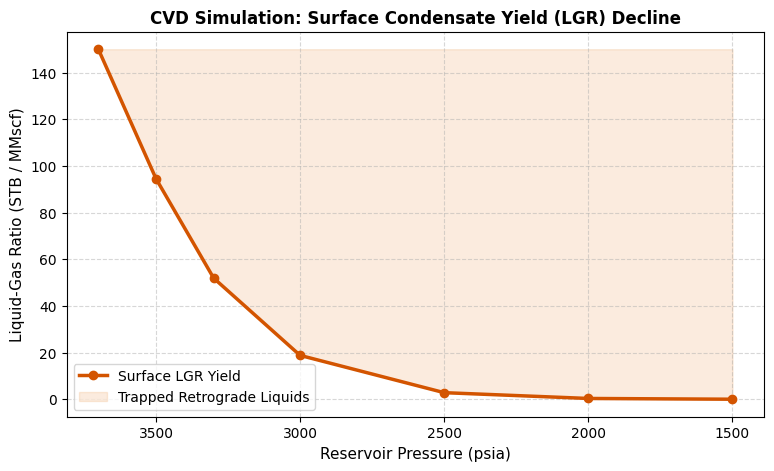

,Reservoir_Pressure_psia,Surface_LGR_STB_MMscf,Liquid_Loss_Pct
0,3700,150.00,0.0
1,3500,94.54,37.0
2,3300,51.94,65.4
3,3000,18.82,87.5
4,2500,2.85,98.1
5,2000,0.36,99.8
6,1500,0.04,100.0


In [3]:
# 1. Input Sample CVD Data (Representing reservoir pressure vs Cumulative Gas Produced)
cvd_pressure = np.array([3700, 3500, 3300, 3000, 2500, 2000, 1500]) # From Dew Point down
# Surface Condensate Yield (STB / MMscf) - This drops because heavy components stay trapped in the reservoir
initial_lgr = 150.0  # Barrels of liquid per Million cubic feet of gas at dew point

# Empirical decline modeling for Condensate Yield due to retrograde loss
def calculate_lgr_decline(P, P_dew, initial_yield, decline_factor=0.0008):
    lgr = np.zeros_like(P, dtype=float)
    for i, p in enumerate(P):
        if p >= P_dew:
            lgr[i] = initial_yield
        else:
            # Physics proxy: LGR drops exponentially as heavy hydrocarbons condense out in the porous medium
            dp = P_dew - p
            lgr[i] = initial_yield * np.exp(-decline_factor * (dp**1.2))
    return lgr

# 2. Run the CVD Liquid Recovery Simulation
predicted_lgr = calculate_lgr_decline(cvd_pressure, P_dew=3700, initial_yield=initial_lgr)

# Create a summary DataFrame for your portfolio
df_cvd = pd.DataFrame({
    "Reservoir_Pressure_psia": cvd_pressure,
    "Surface_LGR_STB_MMscf": np.round(predicted_lgr, 2),
    "Liquid_Loss_Pct": np.round((1 - (predicted_lgr / initial_lgr)) * 100, 1)
})

# 3. Plot the LGR Decline Curve (The Business Impact Curve)
plt.figure(figsize=(9, 5))
plt.plot(cvd_pressure, predicted_lgr, marker='o', color='#d35400', linewidth=2.5, label='Surface LGR Yield')
plt.fill_between(cvd_pressure, predicted_lgr, initial_lgr, color='#e67e22', alpha=0.15, label='Trapped Retrograde Liquids')

plt.title('CVD Simulation: Surface Condensate Yield (LGR) Decline', fontsize=12, weight='bold')
plt.xlabel('Reservoir Pressure (psia)', fontsize=11)
plt.ylabel('Liquid-Gas Ratio (STB / MMscf)', fontsize=11)
plt.gca().invert_xaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.show()

# Display the data table underneath the plot
df_cvd

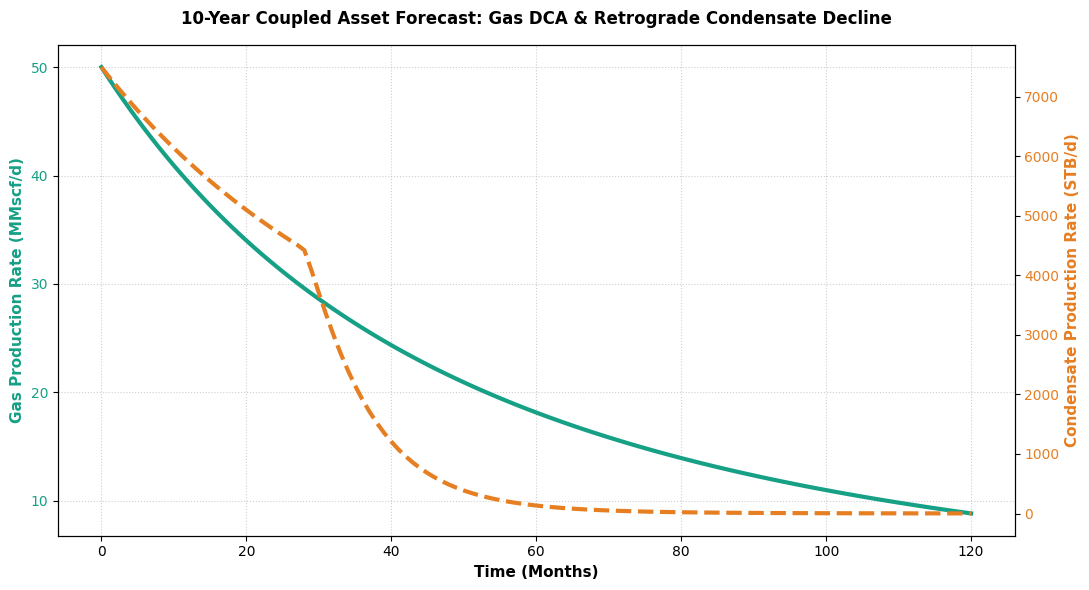

,Month,Estimated_Reservoir_Pressure_psia,Gas_Rate_MMscfd,Condensate_Rate_STBpd
0,0,5000.0,50.00,7500.00
1,1,4943.0,48.97,7346.00
2,2,4888.0,47.98,7196.39
3,3,4833.0,47.01,7051.01
4,4,4779.0,46.06,6909.72
5,5,4725.0,45.15,6772.35
6,6,4673.0,44.26,6638.78
7,7,4621.0,43.39,6508.86
8,8,4570.0,42.55,6382.48
9,9,4520.0,41.73,6259.51


In [4]:
# 1. Setup Time Array (10 Years forecast, sampled monthly)
months = np.arange(0, 121, 1) # 0 to 120 months

# 2. Arps Decline Curve Parameters for the Gas Phase
q_i_gas = 50.0      # Initial Gas Rate (MMscf/day)
d_i_yearly = 0.25   # Initial nominal decline rate per year (25%)
d_i_monthly = d_i_yearly / 12  # Convert to monthly nominal decline
b_factor = 0.4      # Hyperbolic exponent (typical for gas reservoirs, 0 < b < 1)

# Calculate Gas Production Forecast over time using Arps Hyperbolic equation
q_gas_forecast = q_i_gas / ((1 + b_factor * d_i_monthly * months) ** (1 / b_factor))

# 3. Couple the Gas Decline with Reservoir Pressure & LGR Decline
# Proxy: Reservoir pressure drops over time proportional to cumulative gas recovery
p_initial = 5000
p_abandonment = 1200
# Simple pressure depletion model based on gas drainage
pressure_forecast = p_initial - (p_initial - p_abandonment) * (1 - np.exp(-0.015 * months))

# Use our thermodynamic function from the previous step to get changing LGR
p_dew_val = 3700
initial_lgr_val = 150.0
q_condensate_forecast = np.zeros_like(months, dtype=float)

for i, p in enumerate(pressure_forecast):
    # Calculate LGR at this specific time step's pressure
    if p >= p_dew_val:
        current_lgr = initial_lgr_val
    else:
        dp = p_dew_val - p
        current_lgr = initial_lgr_val * np.exp(-0.0008 * (dp**1.2))

    # Condensate Rate (STB/day) = Gas Rate (MMscf/day) * LGR (STB/MMscf)
    q_condensate_forecast[i] = q_gas_forecast[i] * current_lgr

# 4. Compile Forecast into a DataFrame
df_forecast = pd.DataFrame({
    "Month": months,
    "Estimated_Reservoir_Pressure_psia": np.round(pressure_forecast, 0),
    "Gas_Rate_MMscfd": np.round(q_gas_forecast, 2),
    "Condensate_Rate_STBpd": np.round(q_condensate_forecast, 2)
})

# 5. Plot the Coupled Decline Forecast
fig, ax1 = plt.subplots(figsize=(11, 6))

# Gas Profile (Left Axis)
color = '#16a085'
ax1.set_xlabel('Time (Months)', fontsize=11, weight='bold')
ax1.set_ylabel('Gas Production Rate (MMscf/d)', color=color, fontsize=11, weight='bold')
ax1.plot(months, q_gas_forecast, color=color, linewidth=3, label='Gas Forecast (Arps)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Condensate Profile (Right Axis)
ax2 = ax1.twinx()
color = '#e67e22'
ax2.set_ylabel('Condensate Production Rate (STB/d)', color=color, fontsize=11, weight='bold')
ax2.plot(months, q_condensate_forecast, color=color, linewidth=3, linestyle='--', label='Condensate Forecast (Coupled)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('10-Year Coupled Asset Forecast: Gas DCA & Retrograde Condensate Decline', fontsize=12, weight='bold', pad=15)
fig.tight_layout()
plt.show()

# Show the first 2 years of data snapshots
df_forecast.head(25)

In [15]:
# 1. Calculate Cumulative Production using Trapezoidal Integration
# Days in a typical month factor (~30.4) to convert daily rates to monthly volumes
days_in_month = 30.417

cum_gas_produced_mmscf = np.trapezoid(df_forecast["Gas_Rate_MMscfd"], df_forecast["Month"]) * days_in_month
cum_condensate_produced_stb = np.trapezoid(df_forecast["Condensate_Rate_STBpd"], df_forecast["Month"]) * days_in_month

# 2. Estimate Initial Gas/Condensate In Place (IGIP / ICIP) for Recovery Factor
# (Using typical volumetric baselines matching our initial production rates)
igip_mmscf = 120000.0  # 120 Bscf initial gas in place
icip_stb = igip_mmscf * initial_lgr_val # Initial Condensate In Place

# 3. Calculate Recovery Factors
gas_rf = (cum_gas_produced_mmscf / igip_mmscf) * 100
condensate_rf = (cum_condensate_produced_stb / icip_stb) * 100
trapped_liquids_stb = (cum_gas_produced_mmscf * initial_lgr_val) - cum_condensate_produced_stb

print("        ASSET ULTIMATE RECOVERY & EFFICIENCY       ")

print(f" 10-Year Estimated Ultimate Gas Recovery (EUR): {cum_gas_produced_mmscf:,.0f} MMscf")
print(f" 10-Year Estimated Ultimate Condensate EUR:     {cum_condensate_produced_stb:,.0f} STB\n")
print(f" Gas Recovery Factor (RF %):                    {gas_rf:.2f} %")
print(f" Condensate Recovery Factor (RF %):             {condensate_rf:.2f} %")
print(f" Revenue Trapped in Subsurface (Missing Oil):  {trapped_liquids_stb:,.0f} STB")


        ASSET ULTIMATE RECOVERY & EFFICIENCY       
 10-Year Estimated Ultimate Gas Recovery (EUR): 78,654 MMscf
 10-Year Estimated Ultimate Condensate EUR:     6,195,075 STB

 Gas Recovery Factor (RF %):                    65.55 %
 Condensate Recovery Factor (RF %):             34.42 %
 Revenue Trapped in Subsurface (Missing Oil):  5,603,041 STB


/tmp/ipykernel_2453/2759020788.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=recovery_factors, palette='viridis')


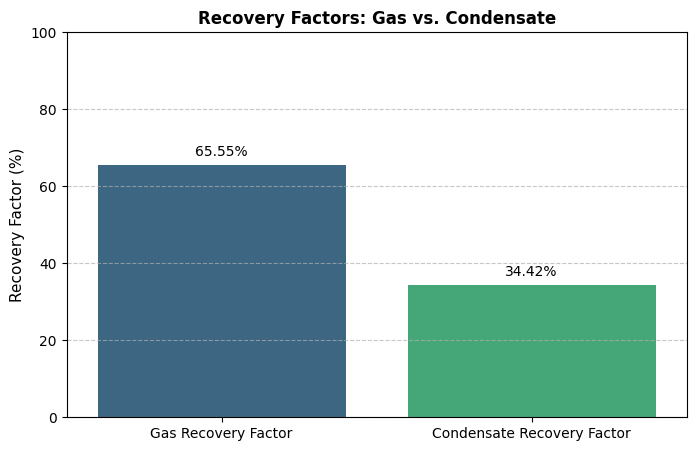

In [12]:
import seaborn as sns

labels = ['Gas Recovery Factor', 'Condensate Recovery Factor']
recovery_factors = [gas_rf, condensate_rf]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=recovery_factors, palette='viridis')
plt.title('Recovery Factors: Gas vs. Condensate', fontsize=12, weight='bold')
plt.ylabel('Recovery Factor (%)', fontsize=11)
plt.ylim(0, 100) # Recovery factors are percentages, so limit to 0-100
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

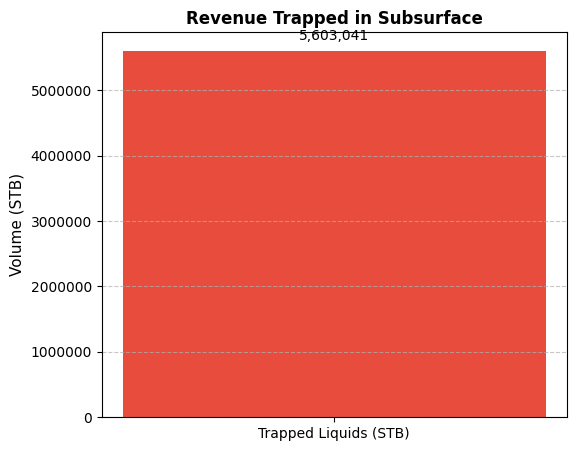

In [14]:
plt.figure(figsize=(6, 5))
ax = plt.bar(['Trapped Liquids (STB)'], [trapped_liquids_stb], color='#e74c3c')
plt.title('Revenue Trapped in Subsurface', fontsize=12, weight='bold')
plt.ylabel('Volume (STB)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis

# Add data label
for p in ax:
    plt.text(p.get_x() + p.get_width() / 2., p.get_height() + (p.get_height() * 0.02),
             f'{p.get_height():,.0f}',
             ha='center', va='bottom', fontsize=10, color='black')

plt.show()

       ASSET LIFECYCLE ECONOMIC SUMMARY           
Total Gross Revenue (10-Year Forecast):   $473,465,569.14
Total Operational Costs (OPEX):           $151,250,000.00
Net Present Value (NPV @ 10% Discount):   $316,678,939.98
Estimated Value of Trapped Subsurface Liquids: $420,228,055.81


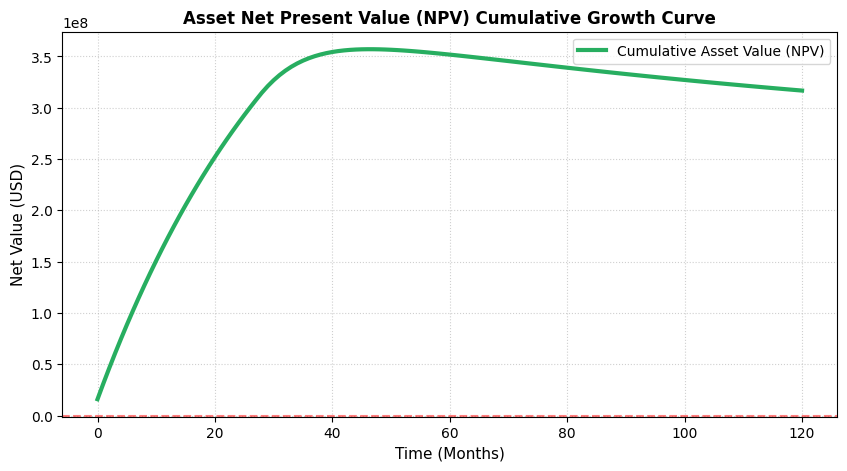

In [17]:
# 1. Economic Boundary Conditions
price_condensate = 75.00  # USD per barrel (STB)
price_gas = 3.50         # USD per MMscf
discount_rate = 0.10     # 10% industry standard discount rate (D10)

# Annual Fixed Operational Expenses (Platform maintenance, logistics, salaries)
annual_opex_base = 15_000_000  # $15 Million / year
monthly_opex = annual_opex_base / 12

# 2. Calculate Monthly Gross Revenues and Net Cash Flows
df_forecast["Gas_Revenue_USD"] = df_forecast["Gas_Rate_MMscfd"] * days_in_month * price_gas
df_forecast["Condensate_Revenue_USD"] = df_forecast["Condensate_Rate_STBpd"] * days_in_month * price_condensate
df_forecast["Total_Gross_Revenue_USD"] = df_forecast["Gas_Revenue_USD"] + df_forecast["Condensate_Revenue_USD"]

# Net Cash Flow = Gross Revenue - Operating Expenses
df_forecast["Net_Cash_Flow_USD"] = df_forecast["Total_Gross_Revenue_USD"] - monthly_opex

# 3. Apply Discounting for Net Present Value (NPV)
# Discount Factor = 1 / (1 + r)^(t_years)
df_forecast["Year"] = df_forecast["Month"] / 12
df_forecast["Discount_Factor"] = 1 / ((1 + discount_rate) ** df_forecast["Year"])
df_forecast["Present_Value_USD"] = df_forecast["Net_Cash_Flow_USD"] * df_forecast["Discount_Factor"]

# 4. Global Asset Metrics
total_gross_revenue = df_forecast["Total_Gross_Revenue_USD"].sum()
total_operating_costs = monthly_opex * len(df_forecast)
asset_npv = df_forecast["Present_Value_USD"].sum()
financial_loss_trapped = trapped_liquids_stb * price_condensate

print("       ASSET LIFECYCLE ECONOMIC SUMMARY           ")

print(f"Total Gross Revenue (10-Year Forecast):   ${total_gross_revenue:,.2f}")
print(f"Total Operational Costs (OPEX):           ${total_operating_costs:,.2f}")
print(f"Net Present Value (NPV @ 10% Discount):   ${asset_npv:,.2f}")
print(f"Estimated Value of Trapped Subsurface Liquids: ${financial_loss_trapped:,.2f}")

# Plot Cumulative Cash Flow over time
plt.figure(figsize=(10, 5))
plt.plot(df_forecast["Month"], df_forecast["Present_Value_USD"].cumsum(), color='#27ae60', linewidth=3, label='Cumulative Asset Value (NPV)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Asset Net Present Value (NPV) Cumulative Growth Curve', fontsize=12, weight='bold')
plt.xlabel('Time (Months)', fontsize=11)
plt.ylabel('Net Value (USD)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()